<a href="https://colab.research.google.com/github/donna6355/study_python/blob/master/senior_sinor_wordclound.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
^C


In [3]:
import pandas as pd

df = pd.read_csv('sinor_10211.csv')
df

,Unnamed: 0,title,content,date,nickName
0,0,친구를 원합니다,나이 기준이 있나요? 알고 덤벼 보고싶네요,2024-05-26 14:38,kim
1,1,노을같은친구,그냥. 여행다니고. 가끔 술. 한잔할 친구를 원합니다\n,2024-05-26 14:45,kim
2,2,같은 지역분들 반가워요,가까운 곳에 사시는 분과 소통하며 일상을 보내고 싶네요,2024-05-26 14:46,살리에르
3,3,NaN,봉숭아 봉숭아 봉숭아,2024-05-26 15:03,바다로
4,4,NaN,충북 괴산,2024-05-26 16:51,젬
...,...,...,...,...,...
6812,6812,싱글 모임 반갑습니다,우리 항상 싱글벙글 하게 싱싱하게\n살아야합니다\nGO GO SING!,2025-03-19 18:23,각자도생
6813,6813,안녕하세요 정원정입니다,함께 하고프네요,2025-03-19 19:18,소라이야기
6814,6814,NaN,아는동생이 작년에 산에서 따온 버섯을 넣고 끓인 베트남 쌀국수 라면입니다..계한도 ...,2025-03-19 19:19,빠달
6815,6815,NaN,어린 날의 사랑은 때로 서툴고 아프다. \n\n지금 돌아보면 그때 나는 너무 어려서...,2025-03-19 22:04,신반장


In [4]:
df['content'] = df['content'].apply(lambda x : x.lower())
df

,Unnamed: 0,title,content,date,nickName
0,0,친구를 원합니다,나이 기준이 있나요? 알고 덤벼 보고싶네요,2024-05-26 14:38,kim
1,1,노을같은친구,그냥. 여행다니고. 가끔 술. 한잔할 친구를 원합니다\n,2024-05-26 14:45,kim
2,2,같은 지역분들 반가워요,가까운 곳에 사시는 분과 소통하며 일상을 보내고 싶네요,2024-05-26 14:46,살리에르
3,3,NaN,봉숭아 봉숭아 봉숭아,2024-05-26 15:03,바다로
4,4,NaN,충북 괴산,2024-05-26 16:51,젬
...,...,...,...,...,...
6812,6812,싱글 모임 반갑습니다,우리 항상 싱글벙글 하게 싱싱하게\n살아야합니다\ngo go sing!,2025-03-19 18:23,각자도생
6813,6813,안녕하세요 정원정입니다,함께 하고프네요,2025-03-19 19:18,소라이야기
6814,6814,NaN,아는동생이 작년에 산에서 따온 버섯을 넣고 끓인 베트남 쌀국수 라면입니다..계한도 ...,2025-03-19 19:19,빠달
6815,6815,NaN,어린 날의 사랑은 때로 서툴고 아프다. \n\n지금 돌아보면 그때 나는 너무 어려서...,2025-03-19 22:04,신반장


In [5]:
# 2. 특수기호, 숫자 제거
import re

remove = re.compile(r'[^a-z가-힣\s\.\!\?]')
df['content'] = df['content'].apply(lambda x : remove.sub(" ",x))
df['content'] = df['content'].apply(lambda x : x.replace("  "," "))
df


,Unnamed: 0,title,content,date,nickName
0,0,친구를 원합니다,나이 기준이 있나요? 알고 덤벼 보고싶네요,2024-05-26 14:38,kim
1,1,노을같은친구,그냥. 여행다니고. 가끔 술. 한잔할 친구를 원합니다\n,2024-05-26 14:45,kim
2,2,같은 지역분들 반가워요,가까운 곳에 사시는 분과 소통하며 일상을 보내고 싶네요,2024-05-26 14:46,살리에르
3,3,NaN,봉숭아 봉숭아 봉숭아,2024-05-26 15:03,바다로
4,4,NaN,충북 괴산,2024-05-26 16:51,젬
...,...,...,...,...,...
6812,6812,싱글 모임 반갑습니다,우리 항상 싱글벙글 하게 싱싱하게\n살아야합니다\ngo go sing!,2025-03-19 18:23,각자도생
6813,6813,안녕하세요 정원정입니다,함께 하고프네요,2025-03-19 19:18,소라이야기
6814,6814,NaN,아는동생이 작년에 산에서 따온 버섯을 넣고 끓인 베트남 쌀국수 라면입니다..계한도 ...,2025-03-19 19:19,빠달
6815,6815,NaN,어린 날의 사랑은 때로 서툴고 아프다. \n\n지금 돌아보면 그때 나는 너무 어려서...,2025-03-19 22:04,신반장


In [6]:
#가입인사 제거, 가입, 반갑
df = df[~df['content'].str.contains(r'반갑|가입', na=False, regex=True)]
df = df.drop(df.columns[0], axis=1)
df


,title,content,date,nickName
0,친구를 원합니다,나이 기준이 있나요? 알고 덤벼 보고싶네요,2024-05-26 14:38,kim
1,노을같은친구,그냥. 여행다니고. 가끔 술. 한잔할 친구를 원합니다\n,2024-05-26 14:45,kim
2,같은 지역분들 반가워요,가까운 곳에 사시는 분과 소통하며 일상을 보내고 싶네요,2024-05-26 14:46,살리에르
3,NaN,봉숭아 봉숭아 봉숭아,2024-05-26 15:03,바다로
4,NaN,충북 괴산,2024-05-26 16:51,젬
...,...,...,...,...
6812,싱글 모임 반갑습니다,우리 항상 싱글벙글 하게 싱싱하게\n살아야합니다\ngo go sing!,2025-03-19 18:23,각자도생
6813,안녕하세요 정원정입니다,함께 하고프네요,2025-03-19 19:18,소라이야기
6814,NaN,아는동생이 작년에 산에서 따온 버섯을 넣고 끓인 베트남 쌀국수 라면입니다..계한도 ...,2025-03-19 19:19,빠달
6815,NaN,어린 날의 사랑은 때로 서툴고 아프다. \n\n지금 돌아보면 그때 나는 너무 어려서...,2025-03-19 22:04,신반장


In [7]:

df['len'] = df['content'].apply(lambda x : len(x))
df = df.loc[df['len']>=12]
del df['len']
df = df.reset_index(drop=True)
df

,title,content,date,nickName
0,친구를 원합니다,나이 기준이 있나요? 알고 덤벼 보고싶네요,2024-05-26 14:38,kim
1,노을같은친구,그냥. 여행다니고. 가끔 술. 한잔할 친구를 원합니다\n,2024-05-26 14:45,kim
2,같은 지역분들 반가워요,가까운 곳에 사시는 분과 소통하며 일상을 보내고 싶네요,2024-05-26 14:46,살리에르
3,친구,대화친구가 필요합니다,2024-05-26 17:34,행복하세요
4,친구가 되고파. 친구가그리워~,진정한 친구를 찾고싶네요,2024-05-26 17:37,행복하세요
...,...,...,...,...
4445,NaN,월드팝장르좋아합니다.\n역사와영혼이깃든 선율 음악이좋아요\n전엔음악방송도 했는데 요...,2025-03-19 17:39,천상정도령
4446,싱글 모임 반갑습니다,우리 항상 싱글벙글 하게 싱싱하게\n살아야합니다\ngo go sing!,2025-03-19 18:23,각자도생
4447,NaN,아는동생이 작년에 산에서 따온 버섯을 넣고 끓인 베트남 쌀국수 라면입니다..계한도 ...,2025-03-19 19:19,빠달
4448,NaN,어린 날의 사랑은 때로 서툴고 아프다. \n\n지금 돌아보면 그때 나는 너무 어려서...,2025-03-19 22:04,신반장


In [28]:
## ===== konlpy 설치 ===== ##
# from google.colab import drive
# drive.mount('/content/drive')

# # 코랩 konlpy 실행
# !curl -s https://raw.githubusercontent.com/teddylee777/machine-learning/master/99-Misc/01-Colab/mecab-colab.sh | bash

# # Mecab 설치 후 Google Drive에 복사
# !cp -r /usr/local/lib/mecab /content/drive/MyDrive/mecab
# !cp -r /usr/local/etc/mecabrc /content/drive/MyDrive/mecab
## ===== konlpy 설치 ===== ##

from konlpy.tag import Okt
from tqdm import tqdm
tqdm.pandas()

okt = Okt()
def extract_pos(text, pos):
  left = []
  for t,c in okt.pos(text, stem = True, norm = True):
    if c in pos:
      left.append(t)
  return left

df["token"] = df["content"].progress_apply(lambda x : extract_pos(x,['Noun','Adjective']))
df

100%|██████████| 4450/4450 [01:00<00:00, 74.02it/s]


,title,content,date,nickName,token
0,친구를 원합니다,나이 기준이 있나요? 알고 덤벼 보고싶네요,2024-05-26 14:38,kim,"[나이, 기준, 있다, 알, 덤벼]"
1,노을같은친구,그냥. 여행다니고. 가끔 술. 한잔할 친구를 원합니다\n,2024-05-26 14:45,kim,"[그냥, 여행, 가끔, 술, 한잔, 친구, 원하다]"
2,같은 지역분들 반가워요,가까운 곳에 사시는 분과 소통하며 일상을 보내고 싶네요,2024-05-26 14:46,살리에르,"[가깝다, 곳, 사시, 분과, 소통, 일상]"
3,친구,대화친구가 필요합니다,2024-05-26 17:34,행복하세요,"[대화, 친구, 필요하다]"
4,친구가 되고파. 친구가그리워~,진정한 친구를 찾고싶네요,2024-05-26 17:37,행복하세요,"[진정하다, 친구]"
...,...,...,...,...,...
4445,NaN,월드팝장르좋아합니다.\n역사와영혼이깃든 선율 음악이좋아요\n전엔음악방송도 했는데 요...,2025-03-19 17:39,천상정도령,"[월드, 팝, 장르, 좋아하다, 역사, 영혼, 깃, 선율, 음악, 좋다, 전, 음악..."
4446,싱글 모임 반갑습니다,우리 항상 싱글벙글 하게 싱싱하게\n살아야합니다\ngo go sing!,2025-03-19 18:23,각자도생,"[우리, 항상, 싱글벙글, 싱싱하다, 살, 야합]"
4447,NaN,아는동생이 작년에 산에서 따온 버섯을 넣고 끓인 베트남 쌀국수 라면입니다..계한도 ...,2025-03-19 19:19,빠달,"[동생, 작년, 산, 버섯, 베트남, 쌀국수, 라면, 이다, 계, 한도, 넣엇어]"
4448,NaN,어린 날의 사랑은 때로 서툴고 아프다. \n\n지금 돌아보면 그때 나는 너무 어려서...,2025-03-19 22:04,신반장,"[날, 사랑, 때, 서툴다, 아프다, 지금, 그때, 나, 사랑, 법, 것, 같다, ..."


In [18]:
!pip install kiwipiepy
from kiwipiepy.utils import Stopwords

stopwords = Stopwords()
sw = set([i[0] for i in stopwords.stopwords])

cleaned_token = []
for i in df["token"]:
  cleaned_token.append([ w for w in i if w not in sw])
df["token"] = cleaned_token
df

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 8.4 MB/s eta 0:00:00
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.22.1-py3-none-any.whl size=79578111 sha256=9005fc843cd84e16b10667d311e17211c535e84c1af0ffe9d3330f6bf5429229
  Stored in directory: /root/.cache/pip/wheels/c0/5a/4b/a1abeb73f3d31c5d010d4163bc08686d5539766084ecba0e1a
Successfully built kiwipiepy_model


,title,content,date,nickName,token
0,친구를 원합니다,나이 기준이 있나요? 알고 덤벼 보고싶네요,2024-05-26 14:38,kim,"[나이, 기준, 있다, 알, 덤벼, 보다]"
1,노을같은친구,그냥. 여행다니고. 가끔 술. 한잔할 친구를 원합니다\n,2024-05-26 14:45,kim,"[그냥, 여행, 다니다, 가끔, 술, 한잔, 하다, 친구, 원하다]"
2,같은 지역분들 반가워요,가까운 곳에 사시는 분과 소통하며 일상을 보내고 싶네요,2024-05-26 14:46,살리에르,"[가깝다, 곳, 사시, 분과, 소통, 하다, 일상, 보내다, 싶다]"
3,친구,대화친구가 필요합니다,2024-05-26 17:34,행복하세요,"[대화, 친구, 필요하다]"
4,친구가 되고파. 친구가그리워~,진정한 친구를 찾고싶네요,2024-05-26 17:37,행복하세요,"[진정하다, 친구, 찾다]"
...,...,...,...,...,...
4445,NaN,월드팝장르좋아합니다.\n역사와영혼이깃든 선율 음악이좋아요\n전엔음악방송도 했는데 요...,2025-03-19 17:39,천상정도령,"[월드, 팝, 장르, 좋아하다, 역사, 영혼, 깃, 선율, 음악, 좋다, 전, 음악..."
4446,싱글 모임 반갑습니다,우리 항상 싱글벙글 하게 싱싱하게\n살아야합니다\ngo go sing!,2025-03-19 18:23,각자도생,"[항상, 싱글벙글, 하다, 싱싱하다, 살, 야합]"
4447,NaN,아는동생이 작년에 산에서 따온 버섯을 넣고 끓인 베트남 쌀국수 라면입니다..계한도 ...,2025-03-19 19:19,빠달,"[알다, 동생, 작년, 산, 따오다, 버섯, 넣다, 끓이다, 베트남, 쌀국수, 라면..."
4448,NaN,어린 날의 사랑은 때로 서툴고 아프다. \n\n지금 돌아보면 그때 나는 너무 어려서...,2025-03-19 22:04,신반장,"[어리다, 날, 사랑, 서툴다, 아프다, 지금, 돌아보다, 그때, 어리다, 사랑, ..."


In [9]:
%pip install wordcloud

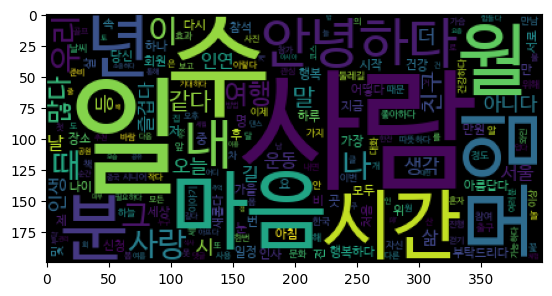

In [30]:

from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

words =[]
for i in df['token']:
    for w in i:
        words.append(w)
# print(words)
# Set font path for Korean characters
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' # Adjust if necessary

count = Counter(words)
del count['이다']
del count['하다']
del count['않다']
del count['그렇다']
del count['되다']
del count['있다']
del count['없다']
del count['싶다']
del count['좋다']
del count['보다']
del count['들다']
del count['가다']
del count['것']
wc = WordCloud(font_path=font_path,)
wc  = wc.generate_from_frequencies(count)
wc = wc.to_array()
plt.imshow(wc)